# 商品类别统计分析

In [8]:
"""
导入模块
"""
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [2]:
%matplotlib inline

In [3]:
"""
绘图设置，中文支持
"""
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
"""
读取数据
"""
df = pd.read_csv("sales_data.csv")

In [8]:
"""
商品类别信息
"""
category_count = df['Category'].nunique()
print("商品类别总数：", category_count)
print("各商品类别名：", df['Category'].unique())

商品类别总数： 5
各商品类别名： ['Electronics' 'Clothing' 'Groceries' 'Toys' 'Furniture']


In [5]:
"""
商品统计信息
"""
category_stats = df.groupby('Category')['Units Sold'].agg(['mean', 'median', 'sum', 'std']).reset_index()
category_stats

,Category,mean,median,sum,std
0,Clothing,94.644161,91.0,1150873,38.624586
1,Electronics,83.041118,79.0,757335,38.282854
2,Furniture,64.375292,61.0,880654,31.462406
3,Groceries,102.872862,97.5,3127335,47.162922
4,Toys,78.447274,77.0,834679,41.581747


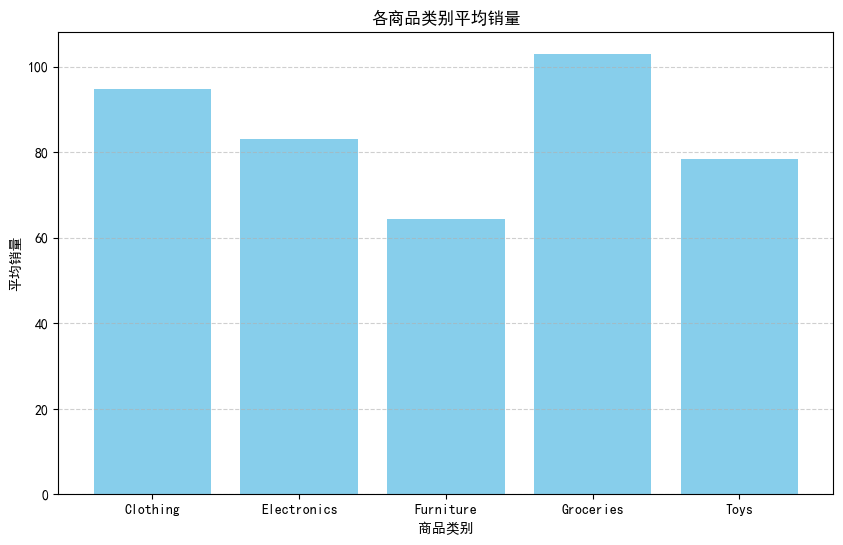

In [9]:
plt.figure(figsize=(10,6))
plt.bar(category_stats['Category'], category_stats['mean'], color='skyblue')
plt.title('各商品类别平均销量')
plt.xlabel('商品类别')
plt.ylabel('平均销量')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

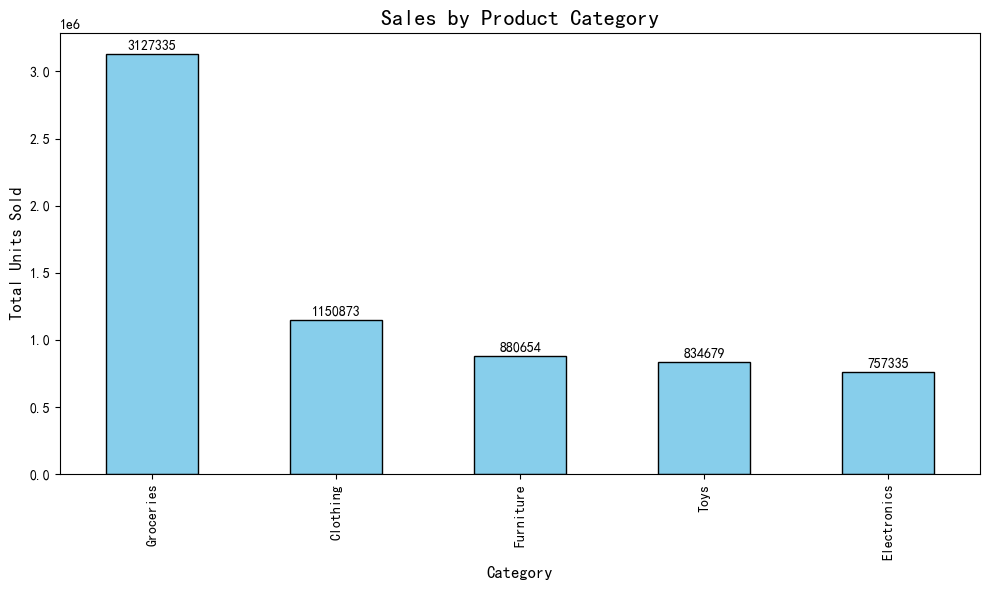

In [5]:
# 按商品类别汇总销量
category_sales = df.groupby('Category')['Units Sold'].sum().sort_values(ascending=False)

# 设置中文字体（避免乱码）
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False  

# 绘制条形图
plt.figure(figsize=(10, 6))
category_sales.plot(kind='bar', color='skyblue', edgecolor='black')

# 添加标题和坐标轴标签
plt.title('Sales by Product Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Units Sold', fontsize=12)

# 在柱顶添加数值标签
for i, v in enumerate(category_sales):
    plt.text(i, v + category_sales.max() * 0.01, f'{v:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


## 计算不同商品类别销量差异的显著性

In [6]:
# 按商品类别分组
groups = [group['Units Sold'].values for name, group in df.groupby('Category')]

# 执行单因素方差分析
f_stat, p_value = stats.f_oneway(*groups)

print(f"F统计量: {f_stat:.4f}")
print(f"P值: {p_value:.6f}")

# 判断显著性
alpha = 0.05
if p_value < alpha:
    print("结论：不同商品类别的销量存在显著差异（拒绝原假设）")
else:
    print("结论：不同商品类别的销量差异不显著（接受原假设）")

F统计量: 2325.1928
P值: 0.000000
结论：不同商品类别的销量存在显著差异（拒绝原假设）


In [7]:
# 使用 Tukey HSD 进行 Post Hoc Test（事后检验）
tukey = pairwise_tukeyhsd(endog=df['Units Sold'], groups=df['Category'], alpha=0.05)
print(tukey)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1      group2   meandiff p-adj  lower    upper   reject
---------------------------------------------------------------
   Clothing Electronics  -11.603   0.0 -13.1722 -10.0338   True
   Clothing   Furniture -30.2689   0.0 -31.6807  -28.857   True
   Clothing   Groceries   8.2287   0.0   7.0132   9.4442   True
   Clothing        Toys -16.1969   0.0 -17.7007 -14.6931   True
Electronics   Furniture -18.6658   0.0 -20.1972 -17.1344   True
Electronics   Groceries  19.8317   0.0  18.4793  21.1842   True
Electronics        Toys  -4.5938   0.0  -6.2104  -2.9773   True
  Furniture   Groceries  38.4976   0.0  37.3313  39.6638   True
  Furniture        Toys   14.072   0.0  12.6077  15.5363   True
  Groceries        Toys -24.4256   0.0 -25.7016 -23.1496   True
---------------------------------------------------------------


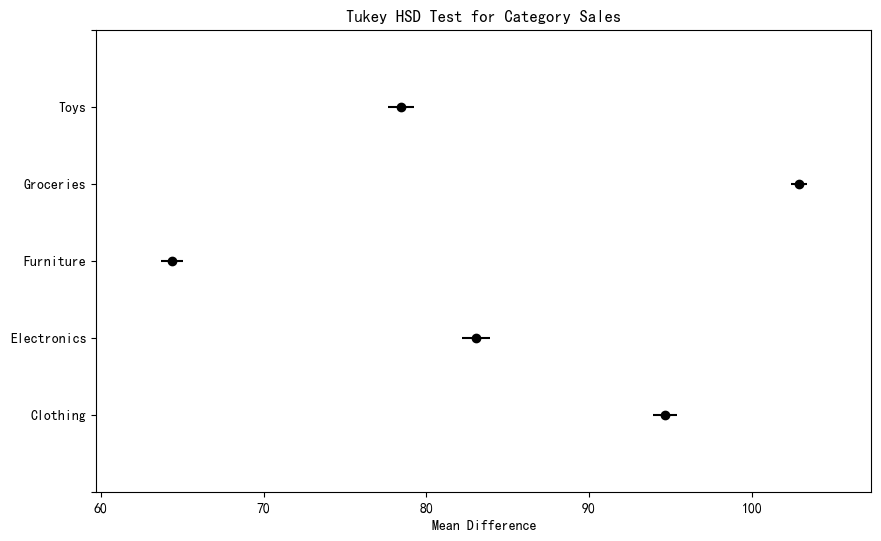

In [9]:
tukey.plot_simultaneous(figsize=(10,6))
plt.title('Tukey HSD Test for Category Sales')
plt.xlabel('Mean Difference')
plt.show()

## 计算类别占比与贡献度

In [10]:
# 计算每个类别的总销量
category_sales = df.groupby('Category')['Units Sold'].sum().reset_index()

# 计算整体销量
total_sales = category_sales['Units Sold'].sum()

# 计算类别占比和贡献度
category_sales['Sales Share (%)'] = category_sales['Units Sold'] / total_sales * 100
category_sales = category_sales.sort_values(by='Units Sold', ascending=False)

# 输出结果
print("各商品类别销量占比与贡献度：")
print(category_sales)


各商品类别销量占比与贡献度：
      Category  Units Sold  Sales Share (%)
3    Groceries     3127335        46.324877
0     Clothing     1150873        17.047758
2    Furniture      880654        13.045033
4         Toys      834679        12.364010
1  Electronics      757335        11.218322


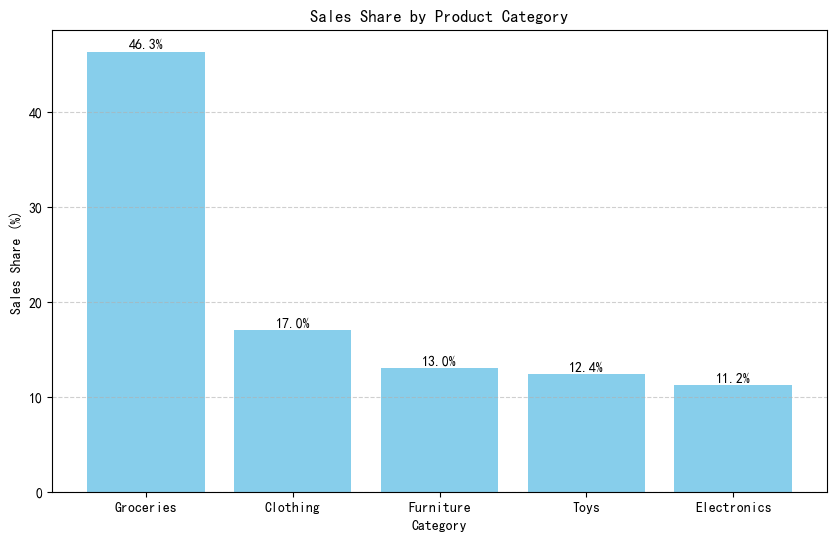

In [11]:
plt.figure(figsize=(10,6))
plt.bar(category_sales['Category'], category_sales['Sales Share (%)'], color='skyblue')
plt.title('Sales Share by Product Category')
plt.xlabel('Category')
plt.ylabel('Sales Share (%)')

# 在柱顶添加数值
for i, v in enumerate(category_sales['Sales Share (%)']):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha='center', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [3]:
# 确保日期列为 datetime 类型
df['Date'] = pd.to_datetime(df['Date'])

# 按日期和类别聚合销量（按天）
category_trend = df.groupby(['Date', 'Category'])['Units Sold'].sum().reset_index()

# 如果想按月汇总
category_trend['Month'] = category_trend['Date'].dt.to_period('M')
monthly_trend = category_trend.groupby(['Month', 'Category'])['Units Sold'].sum().reset_index()
monthly_trend['Month'] = monthly_trend['Month'].dt.to_timestamp()  # 转回 datetime

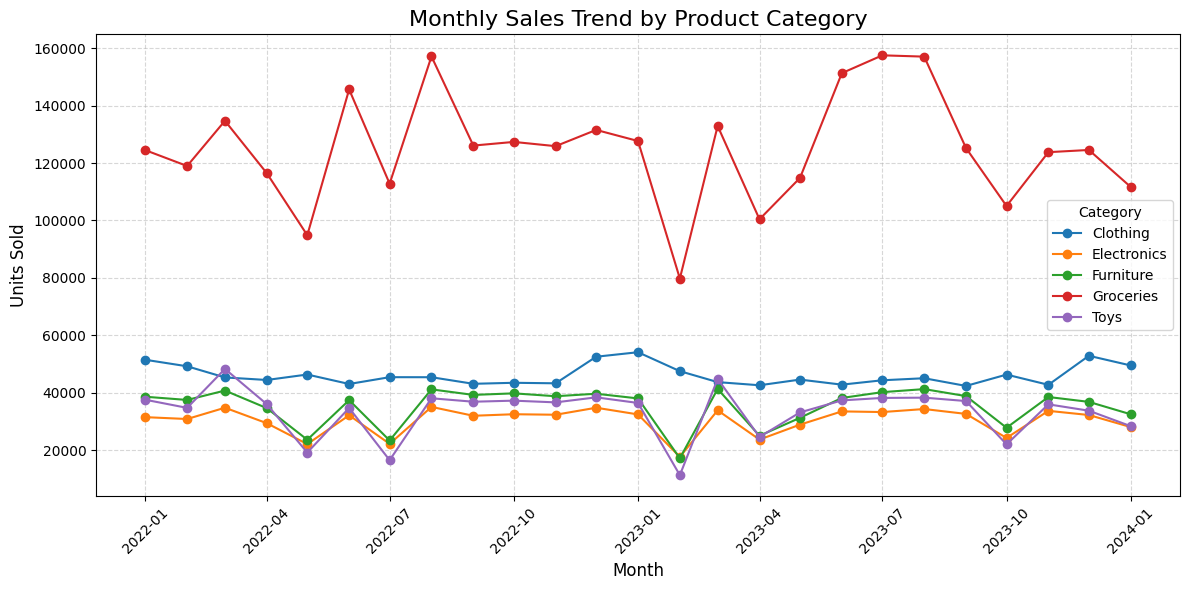

In [5]:
plt.figure(figsize=(12,6))

# 遍历每个类别绘制折线
for category in monthly_trend['Category'].unique():
    temp = monthly_trend[monthly_trend['Category'] == category]
    plt.plot(temp['Month'], temp['Units Sold'], marker='o', label=category)

# 图形美化
plt.title('Monthly Sales Trend by Product Category', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Units Sold', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Category')
plt.tight_layout()
plt.show()